# Exploratory Data Analysis (EDA) with IPUMS USA
### by [Kate Vavra-Musser](https://vavramusser.github.io) for the [R Spatial Notebook Series](https://vavramusser.github.io/r-spatial)

## Introduction
This notebook demonstrates the process of exploratory data analysin using with tabular data.  The notebook uses data extracted from the [IPUMS USA](https://usa.ipums.org/usa) repository, which provides harmonized data from the U.S. Decennial Census, American Community Survey, and Puerto Rico Community Survey, and other sources.  Following data cleaning and preparation, the next step in an analysis workflow is to carry out exploratory data analyses (EDA) which will help you better understand the information contained in your data and potential relationships between variables.  EDA is often carried out as a preliminary step before more nuanced analyses like regression analysis.  This notebook will guide you through key steps in EDA, including exploring variable characteristics and relationships between variables.

### Notebook Goals
This notebook introduces an EDA workflow using previously-downloaded, cleaned, and prepared data from [IPUMS USA](https://usa.ipums.org/usa) data using the [IPUMS API](https://developer.ipums.org/docs/v2/apiprogram) via the [ipumsr R package](https://cran.r-project.org/web/packages/ipumsr/index.html).  This notebook is intended as a follow-up to [Data Cleaning and Preparation with IPUMS USA](https://platform.i-guide.io/notebooks/b4b29b13-d832-495d-8db7-1545a30549f1).  Users will learn how to manage outliers, identify relationships, and calculate EDA statistics for population data in R.  By the end of this notebook, users will have the skills to create their own EDA workflows for tabular IPUMS data or other population datasets for social and demographic research workflows.

### ✨ Prerequisites ✨
* Complete [Introduction to IPUMS and the IPUMS API](https://platform.i-guide.io/notebooks/82d3b176-e4e6-4307-8186-318a3fe6c81a)
* Complete [IPUMS USA Data Extraction Using ipumsr](https://platform.i-guide.io/notebooks/ab5cad39-6d00-43d2-bc51-17fd4e6b98f2)
* Complete [Data Cleaning and Preparation with IPUMS USA](https://platform.i-guide.io/notebooks/b4b29b13-d832-495d-8db7-1545a30549f1)

### 💽 Data Used in this Notebook 💽
* IPUMS USA Example Analysis (*ipums_usa_analysis.rds*)
  * If you worked through [Data Cleaning and Preparation with IPUMS USA](https://platform.i-guide.io/notebooks/b4b29b13-d832-495d-8db7-1545a30549f1) you should have created and saved a copy of *ipums_usa_analysis.rds* in the final section of the notebook.
  * You can also download a copy of *ipums_usa_analysis.rds* file from [the I-GUIDE platform](https://platform.i-guide.io/datasets/25de540c-44a1-4a65-b5af-c772a716e082) or [Kate's GitHub](https://github.com/vavramusser/r-spatial/blob/main/ipums_usa_analysis.rds).

#### About the Example Data Set
The [*ipums_usa_analysis.rds*](https://platform.i-guide.io/datasets/25de540c-44a1-4a65-b5af-c772a716e082) file contains basic demographic information (sex, age, race, educational attainment, and total personal income) on residents of the state of Michigan collected as part of the 2010 [American Community Survey (ACS)](https://www.census.gov/programs-surveys/acs/about.html).  The data has been modified from its original version during data cleaning and preparation steps carried out in [Chapter 3.1](https://platform.i-guide.io/notebooks/b4b29b13-d832-495d-8db7-1545a30549f1).  The ACS is an annual survey conducted by the [U.S. Census Bureau](https://www.census.gov) that collects information on a subset of the U.S. population.  It is a more in-depth supplement to the [U.S. Decennial Census](https://www.census.gov/programs-surveys/decennial-census.html) and in 2005 replaced the long-form version of the Decennial Census survey which was previously conducted every ten years.

### Notebook Overview
1. Setup
2. Summary Statistics

## 1. Setup
This section will guide you through the process of installing essential packages.

[**haven**](https://cran.r-project.org/web/packages/haven/index.html) · Import foreign statistical formats into R via the embedded ["ReadStat"](https://github.com/WizardMac/ReadStat) C library.  This notebook uses the the following functions from *haven*.

### 1a. Install and Load Required Packages
If you have not already installed the required packages, uncomment and run the code below:

In [98]:
# install.packages("dplyr", "ggplot2", "gridExtra", "haven")

Load the packages into your workspace.

In [99]:
library(dplyr)
library(ggplot2)
library(gridExtra)
library(haven)

### 1b. Read in the Data File

Run the following line of code to read in the *ipums_usa_analysis.rds* file into memory.  You may need to update the file path to reflect the file's location on your machine or in your working directory.

In [100]:
dat <- readRDS("ipums_usa_analysis.rds")

### 1c. Review the Data

As a reminder, the data included in the *ipums_usa_analysis.rds* file was initially downloaded from IPUMS USA via API in [Chapter 2.1](https://platform.i-guide.io/notebooks/ab5cad39-6d00-43d2-bc51-17fd4e6b98f2) and later modified during data cleaning and preparation steps in [Chapter 3.1](https://platform.i-guide.io/notebooks/b4b29b13-d832-495d-8db7-1545a30549f1).  The data is derived from the 2010 ACS and was subset to only the state of Michigan.  After Chapter 3.1 the data includes the following variables:

**Variable List**
* [State FIPS Code (STATEFIP)](https://en.wikipedia.org/wiki/Federal_Information_Processing_Standard_state_code)
* [Public Use Microdata Area (PUMA)](https://www.census.gov/programs-surveys/geography/guidance/geo-areas/pumas.html#:~:text=Public%20Use%20Microdata%20Areas%20(PUMAs)%20are%20non%2Doverlapping%2C,%2C%20Puerto%20Rico%2C%20and%20Guam.)
* Sex (SEX)
* Age (AGE)
* Age Categories (AGE_CAT) derived from the AGE variable in [Chapter 3.1](https://platform.i-guide.io/notebooks/b4b29b13-d832-495d-8db7-1545a30549f1)
* Race Categories (RACE_RECODE) derived from the RACE variable in [Chapter 3.1](https://platform.i-guide.io/notebooks/b4b29b13-d832-495d-8db7-1545a30549f1)
* Educatioal Attainment Categories (EDUC_RECODE) derived from the EDUC variable in [Chapter 3.1](https://platform.i-guide.io/notebooks/b4b29b13-d832-495d-8db7-1545a30549f1)
* Total Personal Income (INCTOT)
* Total Personal Income Categories (INC_TOT) derived from the INCTOT variable in [Chapter 3.1](https://platform.i-guide.io/notebooks/b4b29b13-d832-495d-8db7-1545a30549f1)

Let's check out the dimensions of the data.

In [101]:
dim(dat)

[1] 98973     9

The data includes information on 9 variables for 98,973 individuals in the state of Michigan in 2010.

## 2. Summary Statistics

Before we get into more serious EDA steps, let's take a look at a summary of the data which will provide us with a quick snapshot of the variables included in the file.

In [102]:
summary(dat)

    STATEFIP       PUMA           SEX             AGE            AGE_CAT     
 Min.   :26   Min.   : 100   Min.   :1.000   Min.   : 0.00   under 18:21988  
 1st Qu.:26   1st Qu.:1100   1st Qu.:1.000   1st Qu.:19.00   18-24   : 8137  
 Median :26   Median :2400   Median :2.000   Median :42.00   25-44   :22126  
 Mean   :26   Mean   :2231   Mean   :1.512   Mean   :40.65   45-64   :30089  
 3rd Qu.:26   3rd Qu.:3300   3rd Qu.:2.000   3rd Qu.:59.00   65+     :16633  
 Max.   :26   Max.   :4104   Max.   :2.000   Max.   :94.00                   
                                                                             
                             RACE_RECODE   
 White                             :83953  
 Black                             : 9186  
 American Indian or Native American:  739  
 Asian or Pacific Islander         : 2126  
 Other Race                        :  811  
 Two or More Races                 : 2158  
                                           
                        

From this we can see that the age (AGE) and total personal income (INCTOT) variables are numeric and the sex (SEX), age category (AGE_CAT), race category (RACE_RECODE), and total personal income category (INCTOT_CAT) variables are all categorical.  The geographic reference values State FIPS Code (STATEFIP) and Public Use Microdata Area (PUMA) variables are also numeric and correspond to identification codes for state and PUMA geographies.

We can also see the number of missing values for each variable.  Most variables have no missing values but the educational attainment category variable (EDUC_RECODE) is missing for 3,081 individuals (< 1% of the data), the total personal income variable (INCTOT) is missing for 17688 individuals (1.8% of the data), and the total personal income category variable (INCTOT_CAT) is missing for 17939 individuals (1.8% of the data).

### 2a. Measures of Central Tendency and Dispersion (Spread)

We can also use individual functions for each of the summary statisitcs.  Let's check out some summary statistics for the age variable (AGE).

In [103]:
# measures of central tendency
paste("mean:", round(mean(dat$AGE), 1))
paste("median:", median(dat$AGE))

[1] "mean: 40.6"

[1] "median: 42"

In [104]:
# measures of spread
paste("varaince:", round(var(dat$AGE), 1))
paste("standard deviation:", round(sd(dat$AGE), 1))
paste("inter-quartile range:", IQR(dat$AGE))

[1] "varaince: 548.4"

[1] "standard deviation: 23.4"

[1] "inter-quartile range: 40"

### 2b. Measures of Position


In [105]:
paste("minimum:", min(dat$AGE))
paste("maximum:", max(dat$AGE))

[1] "minimum: 0"

[1] "maximum: 94"

The *quantile* function to return percentiles based on whatever probability levels we specify.

In [106]:
# default quantiles (0th, 25th, 50th, 75th, and 100th percentiles)
quantile(dat$AGE)

# user-specified percentiles
quantile(dat$AGE, probs = c(0.01, 0.05, 0.10, 0.90, 0.95, 0.99))

0%  25%  50%  75% 100% 
   0   19   42   59   94

1%  5% 10% 90% 95% 99% 
  1   4   9  71  79  88

Viewing summary statistics are useful to get an idea of the structure and characteristics of our data but using the functions in R also make it easy to extract and store specific statistics to use later in our analysis.  For example, we will later create a density plot of the total personal income (INCTOT) variable and may want to add horizontal lines to the chart indicating the mean and median of the INCTOT variable.  Using the functions we could save the mean and median values as objects which we will later pass to the density plot function or we could pass the values directly to the plot by calling the summary statistic functions on the fly.  We will explore this more in the Data Visualization section of this notebook.

### 2c. Variable Correlations

In [107]:
cor(dat$PUMA, dat$INCTOT, use = "complete.obs", method = "pearson")

[1] 0.05319777

## 3. Data Visualization

### 2a. Histograms

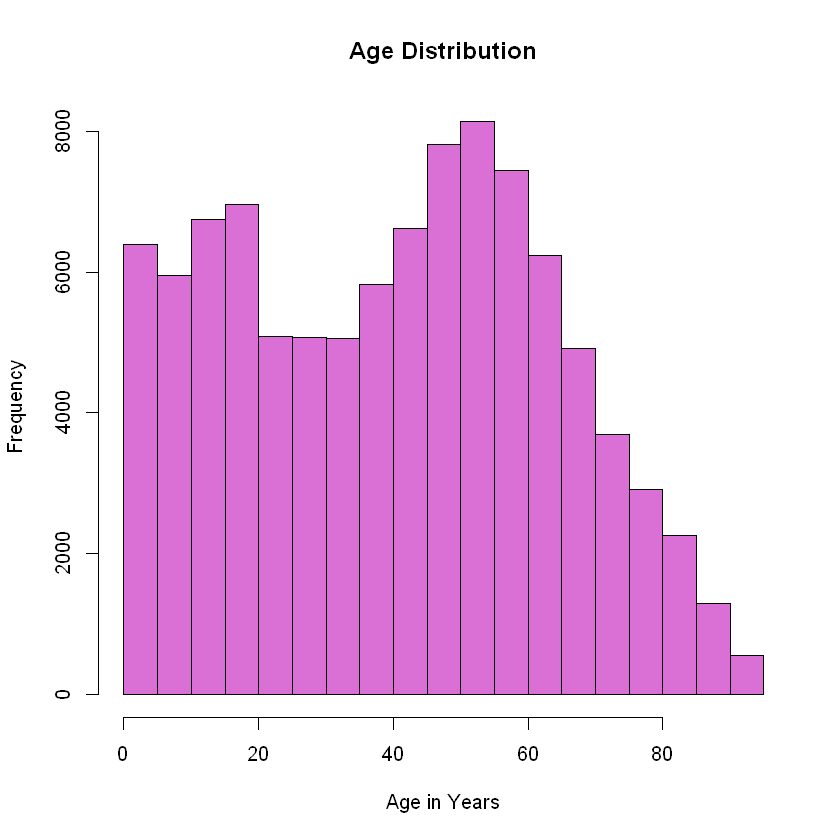

In [108]:
hist(dat$AGE,
     breaks = 25,
     main = "Age Distribution",
     xlab = "Age in Years",
     col = "orchid")     # fill color for the histogram bars

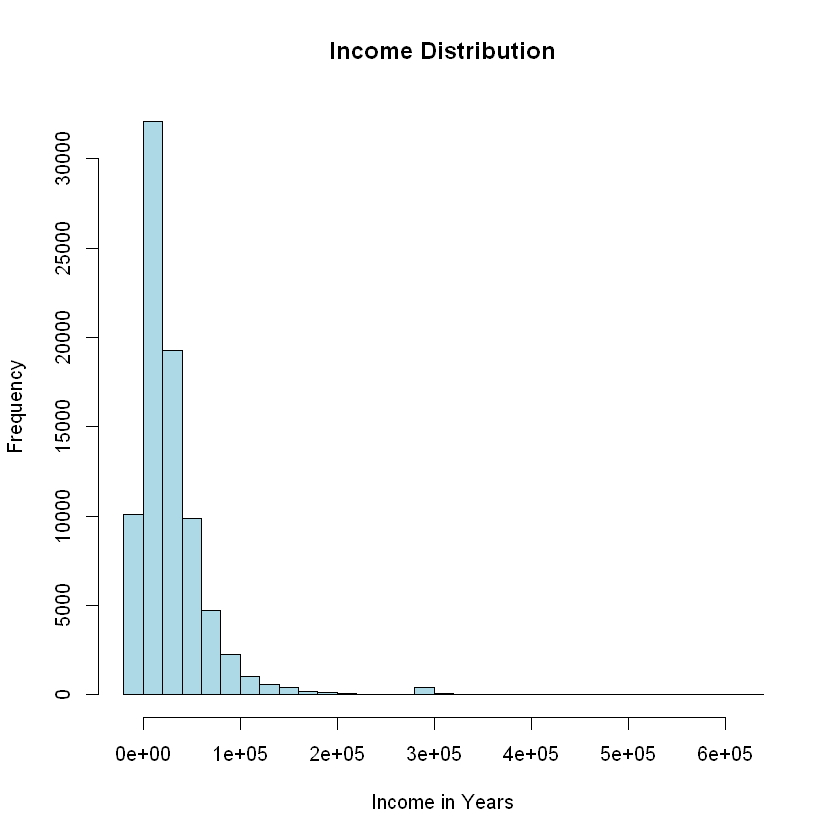

In [109]:
hist(dat$INCTOT,
     breaks = 25,
     main = "Income Distribution",
     xlab = "Income in Years",
     col = "lightblue")

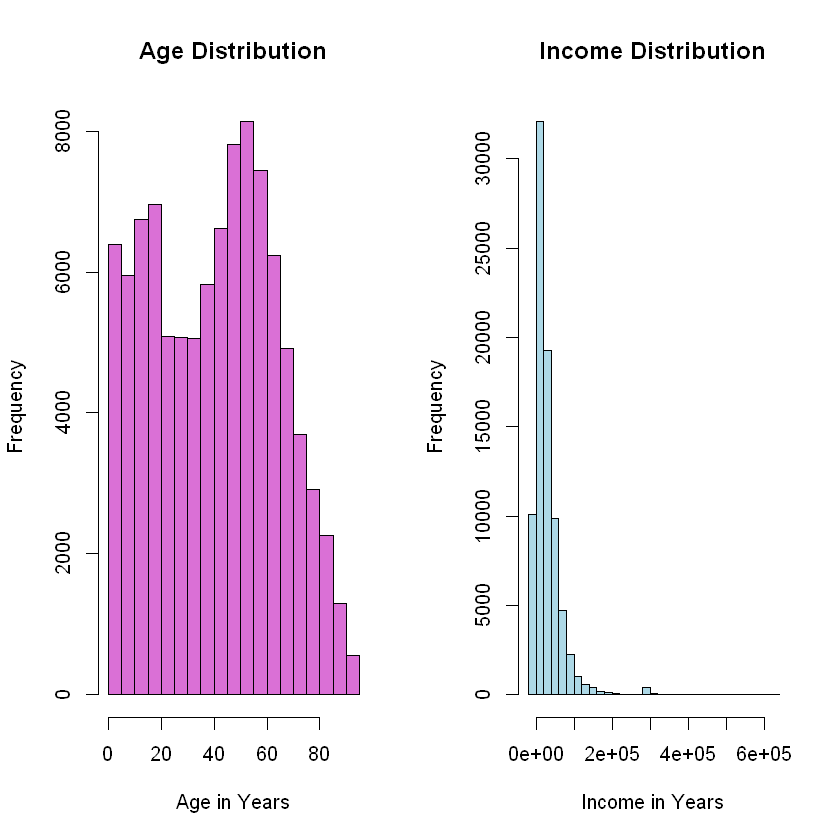

In [110]:
# set the plot space to 1 row and 2 columns
# the two histograms will appear side-by-side
par(mfrow = c(1, 2))

# histogram for age
hist(dat$AGE,
     breaks = 25,
     main = "Age Distribution",
     xlab = "Age in Years",
     col = "orchid")

# histogram for total income
hist(dat$INCTOT,
     breaks = 25,
     main = "Income Distribution",
     xlab = "Income in Years",
     col = "lightblue")

# reset the plot space back to the 1 x 1 default
par(mfrow = c(1, 1))

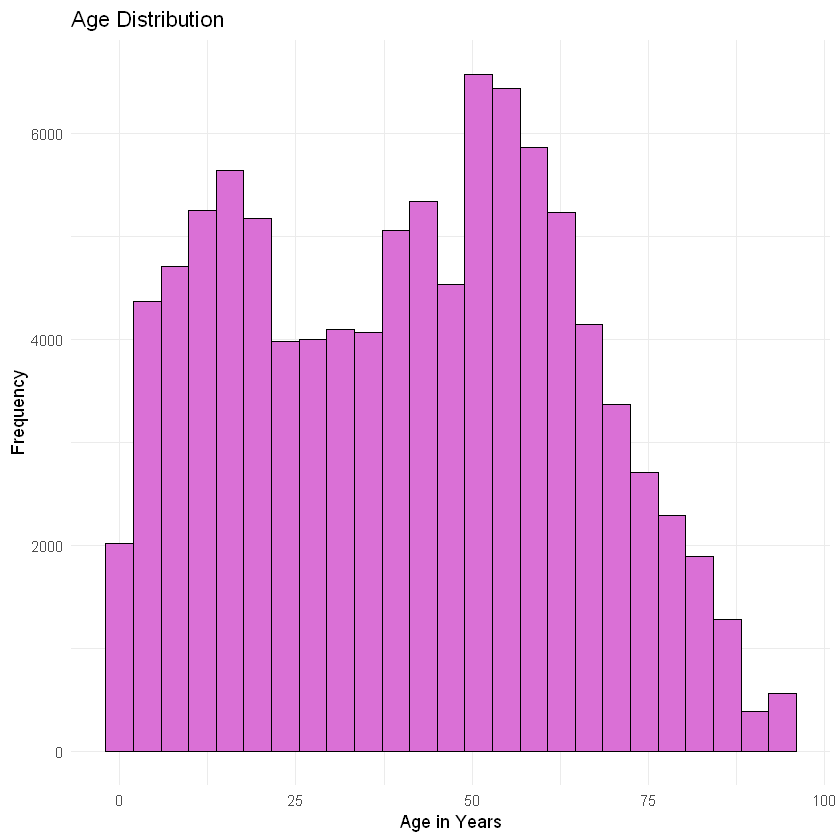

In [111]:
ggplot(dat, aes(x = AGE)) +
  geom_histogram(bins = 25,
                 fill = "orchid",       # fill color for the histogram bars
                 color = "black") +     # border color for the histogram bars
  labs(title = "Age Distribution",
       x = "Age in Years",
       y = "Frequency") +
    theme_minimal()

In [112]:
mean(dat$INCTOT, na.rm = T)
sd(dat$INCTOT, na.rm = T)

[1] 29656.74

[1] 38133.52

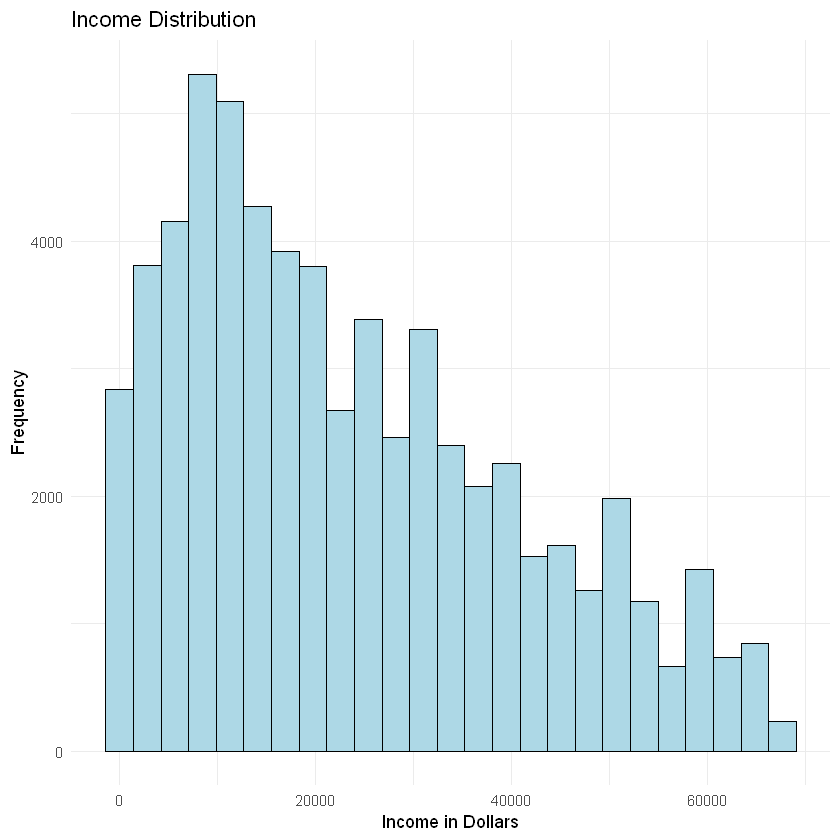

In [113]:
dat %>%
    filter(INCTOT <= mean(dat$INCTOT, na.rm = T) + sd(dat$INCTOT, na.rm = T) & INCTOT > 0) %>%
    ggplot(aes(x = INCTOT)) +
        geom_histogram(bins = 25,
                       fill = "lightblue",
                       color = "black") +
        labs(title = "Income Distribution",
             x = "Income in Dollars",
             y = "Frequency") +
    theme_minimal()

### Gping In-Depth: Exploring Age by State

As we begin to explore our data and visualize the patterns, we might start to have questions about how variables interact with one another.  The EDA phase is a great time to be curious and explore any relationships which might seem interesting.  It doesn't matter if you plan to specifically analyze that relationship in your final analysis.  Any data exploration will help you better understand the structure of your data and that, in turn, will allow you to more effectively approach your data during final data analysis.

Let's start by getting curious about a potential relationship between age and location.  Do some states have a younger age distribution in their population?

First, we will rearrange our data, grouping it by state (STATEFIIP), summarizing age for each state by calculating the mean and median age, and then arranging the states by mean age in descending order (from the "oldest" to the "youngest" state).

In [114]:
# List of mean and median age by state, sorted by mean age
dat %>%
  group_by(STATEFIP) %>%
  summarize(mean_age = mean(AGE, na.rm = TRUE),
            median_age = median(AGE, na.rm = TRUE)) %>%
  arrange(desc(mean_age)) %>%
  print(n = Inf)

# A tibble: 1 x 3
  STATEFIP      mean_age median_age
  <int+lbl>        <dbl>      <int>
1 26 [Michigan]     40.6         42


There is a wide range between the minimum and maximum age by state.  The "oldest" state is Maine with a mean and median age of 46.6 and 51 years respectively while the "youngest" state is Utah with a mean and median age of 35.8 and 33, respectively.  That's a huge difference between the two states.

Let's take a look at the age distributions for the two states and compare their differences.  We will use the *ggplot* function *grom_histogram()* again, use the *ggplot* function *geom_vline()* to create vertical lines in the plots to represent the means and medians for the two states, and use the *grid.arrange()* function from the *gridExtra* package to arrange the two histograms on on top of the other in the same graphic.

Warning message:
"Removed 1 rows containing missing values (`geom_vline()`)."
Warning message:
"Removed 1 rows containing missing values (`geom_vline()`)."
Warning message:
"Removed 1 rows containing missing values (`geom_vline()`)."
Warning message:
"Removed 1 rows containing missing values (`geom_vline()`)."


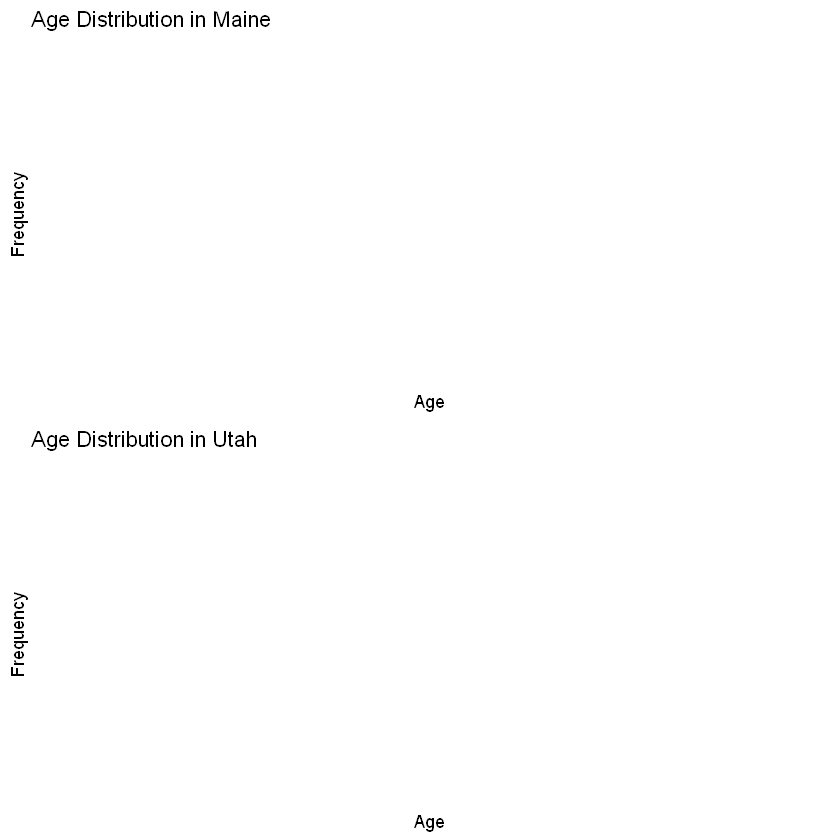

In [115]:
# histogram of Maine age distribution
hist_maine <- ggplot(filter(dat, STATEFIP == 23), aes(x = AGE)) +
  geom_histogram(bins = 25, fill = "lightblue", color = "black") +
  labs(title = "Age Distribution in Maine", x = "Age", y = "Frequency") +
  geom_vline(xintercept = mean(filter(dat, STATEFIP == 23)$AGE, na.rm = T), color = "red", linewidth = 1) +
  geom_vline(xintercept = median(filter(dat, STATEFIP == 23)$AGE, na.rm = T), color = "blue", linewidth = 1) +
  theme_minimal()
    
# histogram of Utah age distribution
hist_utah <- ggplot(filter(dat, STATEFIP == 49), aes(x = AGE)) +
  geom_histogram(bins = 25, fill = "lightgoldenrod", color = "black") +
  labs(title = "Age Distribution in Utah", x = "Age", y = "Frequency") +
  geom_vline(xintercept = mean(filter(dat, STATEFIP == 49)$AGE, na.rm = T), color = "red", linewidth = 1) +
  geom_vline(xintercept = median(filter(dat, STATEFIP == 49)$AGE, na.rm = T), color = "blue", linewidth = 1) +
  theme_minimal()

# arrange the histograms in two rows
grid.arrange(hist_maine, hist_utah, nrow = 2)

Viewing the two histograms shows us that these two states have very different age demographics.  The largest age group in Maine appears to be in the range of about 50 to 75 while the largest age group in Utah appears to be 25 and younger.

### 2b. Box Plots

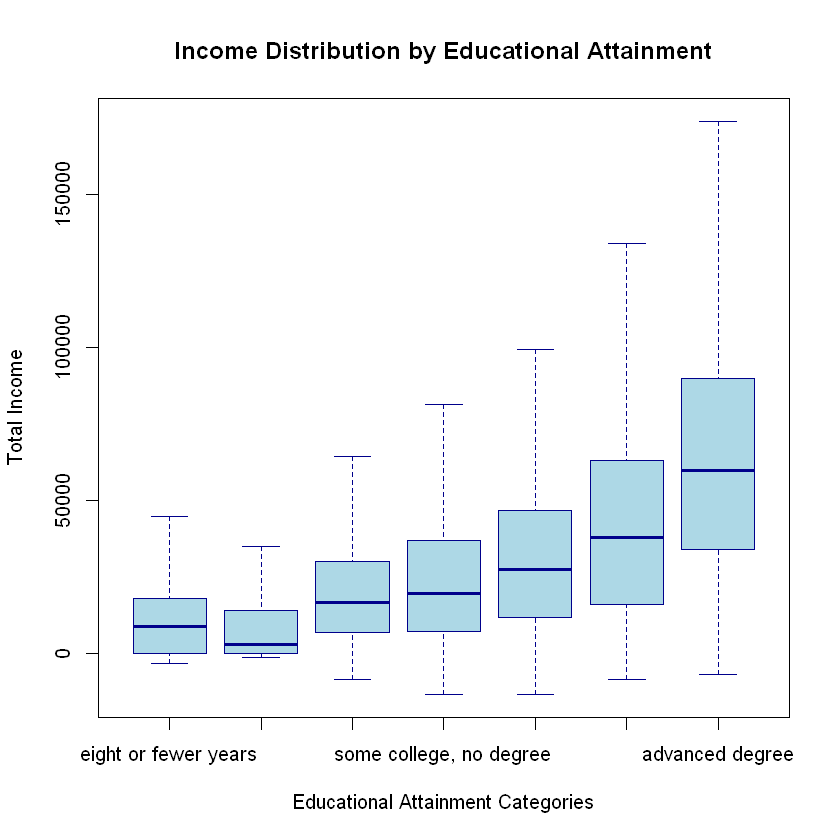

In [116]:
boxplot(INCTOT ~ EDUC_RECODE, data = dat,
        main = "Income Distribution by Educational Attainment",
        xlab = "Educational Attainment Categories",
        ylab = "Total Income",
        col = "lightblue",      # fill color for the boxes
        border = "darkblue",    # border color for the boxes
        outline = FALSE)        # excludes outliers for a cleaner look

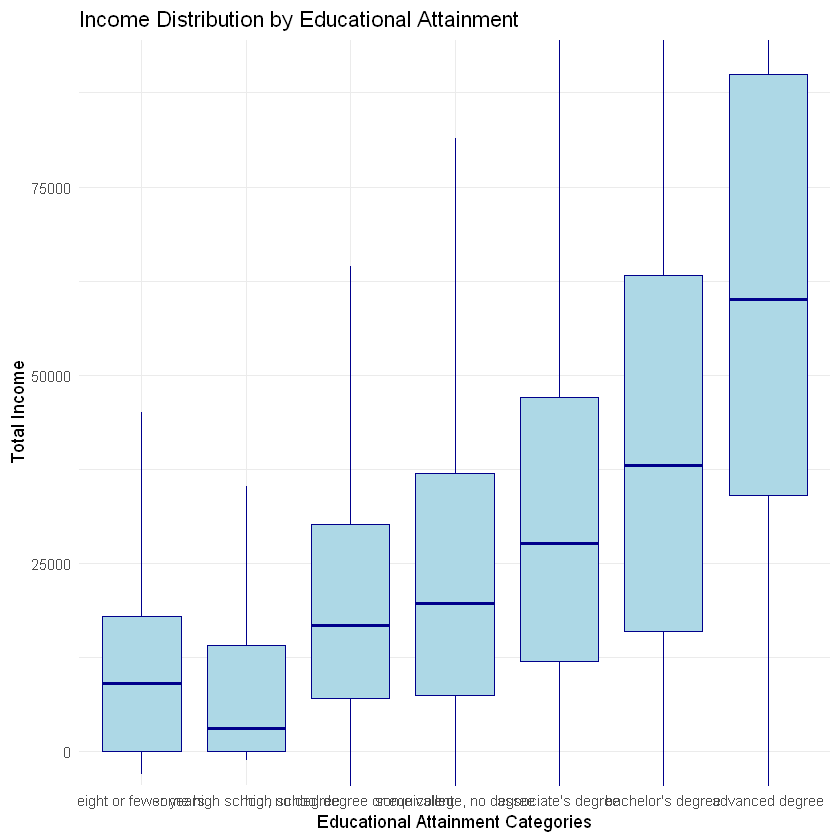

In [117]:
y_limit <- quantile(dat$INCTOT, 0.95, na.rm = T)

dat %>%
filter(!is.na(INCTOT)) %>%
ggplot(aes(x = EDUC_RECODE, y = INCTOT)) +
  geom_boxplot(fill = "lightblue", color = "darkblue", outlier.shape = NA) +
  labs(title = "Income Distribution by Educational Attainment",
       x = "Educational Attainment Categories",
       y = "Total Income") +
  coord_cartesian(ylim = c(0, y_limit)) +
  theme_minimal()

### 2c. Scatter Plots

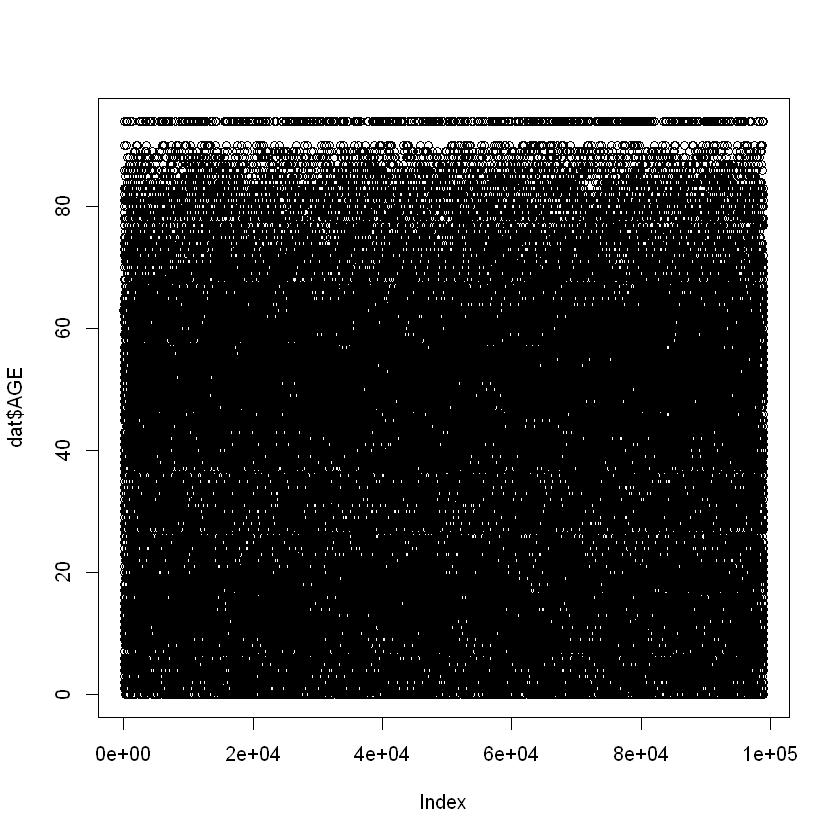

In [118]:
plot(dat$AGE)

In [119]:
ggplot2::geom_point()

geom_point: na.rm = FALSE
stat_identity: na.rm = FALSE
position_identity 

### 2d. Density Plots:

In [120]:
ggplot2::geom_density()

geom_density: na.rm = FALSE, orientation = NA, outline.type = upper
stat_density: na.rm = FALSE, orientation = NA
position_identity 

## 3. Correlation Analysis

### 3a. Correlation Matricies

In [121]:
#cor()

In [122]:
#corrplot::corrplot()

### 3b. Heatmaps

In [123]:
#GGally::ggpairs()

## 4. Outlier Detection

In [124]:
#boxplot()

In [125]:
#dplyr::filter()

In [126]:
#ggplot2::geom_boxplot()

## 5. Categorical Variable Analysis

In [127]:
#table()

In [128]:
#prop.table()

In [129]:
#ggplot2::geom_bar

## 5. Exploring Relationships in Depth

### Exploring Educational Attainmennt by Age Group

Taking a look at the education information, you might notice that there seem to be a suprisingly high number of individuals with very little education.

In [ ]:
#calculate_percentage(dat, EDUC_RECODE)

ERROR: Error in calculate_percentage(dat, EDUC_RECODE): could not find function "calculate_percentage"


25.01% (16.57% + 8.44%) of the population has not completed a high school degree or equivalent! This seems very high for 2017-2022. A quick search shows us that in 2021 only 8.9% of the population had less than a high school degree or equivalent.

That number is way too high because we have children in the sample! Our review of the AGE variable, showed us that many of the individuals in this sample are too young to have even started school, let alone complete a degree. Unless we are specifically intersted in tracking educational attainment for children, it probably isn't very useful to include children when we analyze the EDUC_RECODE variable.

When exploring educational attainment, it's common to only look at individuals aged 25 and older and if you clicked the link above you may have noticed that the website specifies that the 8.9% statistic is for ages 25 and older. Population level educational attainment research is usually focused on high school completion and college completion and, for the most part, individuals usually complete these degrees by age 25 if they plan to complete them at all.

Let's take another look at the education variable, but restricting to only individuals aged 25 or older. We are also excluding the missing (N/A) category for this view and focus only on the individuals for which we have educational attainment information.

In [ ]:
#calculate_percentage(filter(dat, AGE >= 25 & !is.na(EDUC_RECODE)), EDUC_RECODE)

After restricing the data to only individuals aged 25 or older we can see that only 10.31% (4.35% + 5.96%) have not achieved a high school degree or equivalent.  This is close to the statistic provided above and makes much more sense given contemporary educational attainment rates.

We can dig even deeper and compare age category and educational attainment category.

First we will make a new helper function to produce cross-tabulations with percents.

In [131]:
calculate_percentage_cross_tab <- function(data, var1, var2) {
  data %>%
    count({{ var1 }}, {{ var2 }}) %>%
    group_by({{ var1 }}) %>%
    mutate(Percentage = n / sum(n) * 100) %>%
    ungroup()
}

Then we can take a look at educational attainment by age category.

In [132]:
calculate_percentage_cross_tab(filter(dat, AGE >= 25), AGE_CAT, EDUC_RECODE) %>% print(n = Inf)

# A tibble: 21 x 4
   AGE_CAT EDUC_RECODE                          n Percentage
   <fct>   <fct>                            <int>      <dbl>
 1 25-44   eight or fewer years               475       2.15
 2 25-44   some high school, no degree       1381       6.24
 3 25-44   high school degree or equivalent  5752      26.0 
 4 25-44   some college, no degree           5901      26.7 
 5 25-44   associate's degree                2102       9.50
 6 25-44   bachelor's degree                 4363      19.7 
 7 25-44   advanced degree                   2152       9.73
 8 45-64   eight or fewer years               640       2.13
 9 45-64   some high school, no degree       1723       5.73
10 45-64   high school degree or equivalent  9984      33.2 
11 45-64   some college, no degree           7359      24.5 
12 45-64   associate's degree                2898       9.63
13 45-64   bachelor's degree                 4521      15.0 
14 45-64   advanced degree                   2964       9.85
15 65

This cross-tabulation shows us that younger adults are completing more education than the older generations.  Fewer members of the younger generation have not completed high school and more have completed a bachelor's degree.

Percent of the population with no high school diploma or equivalent:
* 8.68% (3.17% + 5.51%) of the 25-44 population
* 10.25% (4.30% + 5.95%) of the 45-64 population
* 12.20% (5.74% + 6.46%) of the 65+ population

Percent of the population with a Bachelor's degree or more:
* 40.6% (25.7% + 14.9%) of the 25-44 population
* 36.6% (20.0% + 13.6%) of the 45-64 population
* 30.0% (16.3% + 13.7%) of the 65+ population

Let's use *ggplot* to create a stacked bar chat showing educational attainment category by age group.

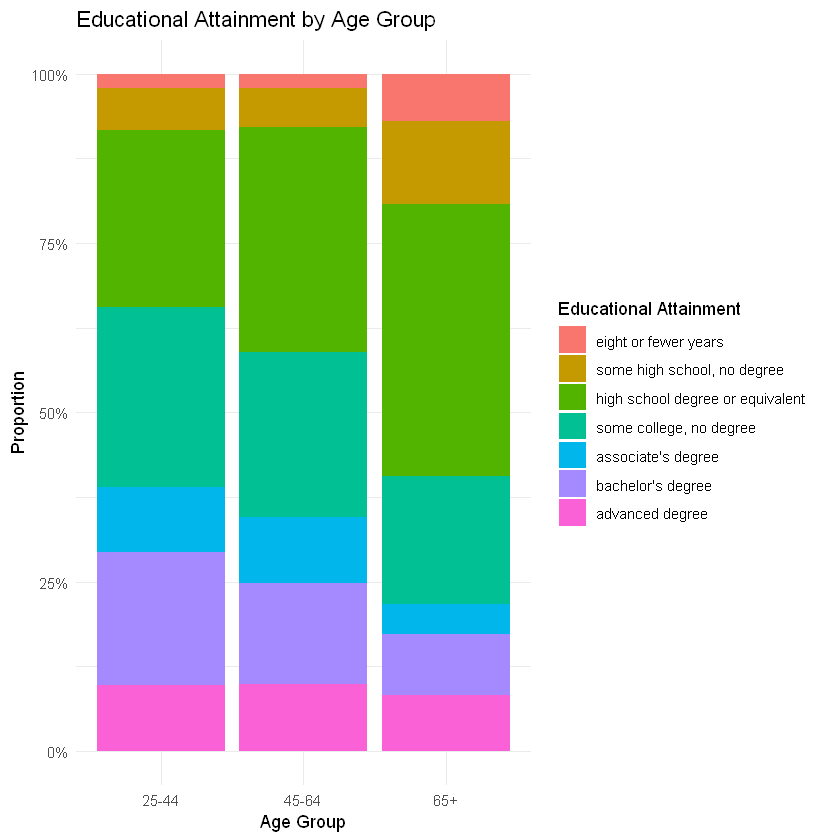

In [133]:
# stacked bar chart comparing age groups and educational attainment
ggplot(filter(dat, AGE >= 25), aes(x = AGE_CAT, fill = EDUC_RECODE)) +
  geom_bar(position = "fill") +
  labs(title = "Educational Attainment by Age Group",
       x = "Age Group",
       y = "Proportion",
       fill = "Educational Attainment") +
  scale_y_continuous(labels = scales::percent_format()) +
  theme_minimal()

The stacked bar chart confirms what we saw in the cross-tabulation and shows a shift of educational attainment by generation.  The most common educational attainment level for individuals aged 25-44 is a Bachelor's degree compared to a high school degree or equivalent for individuals aged 65+.

Let's break this down further by exploring these trends seperately for men and women.

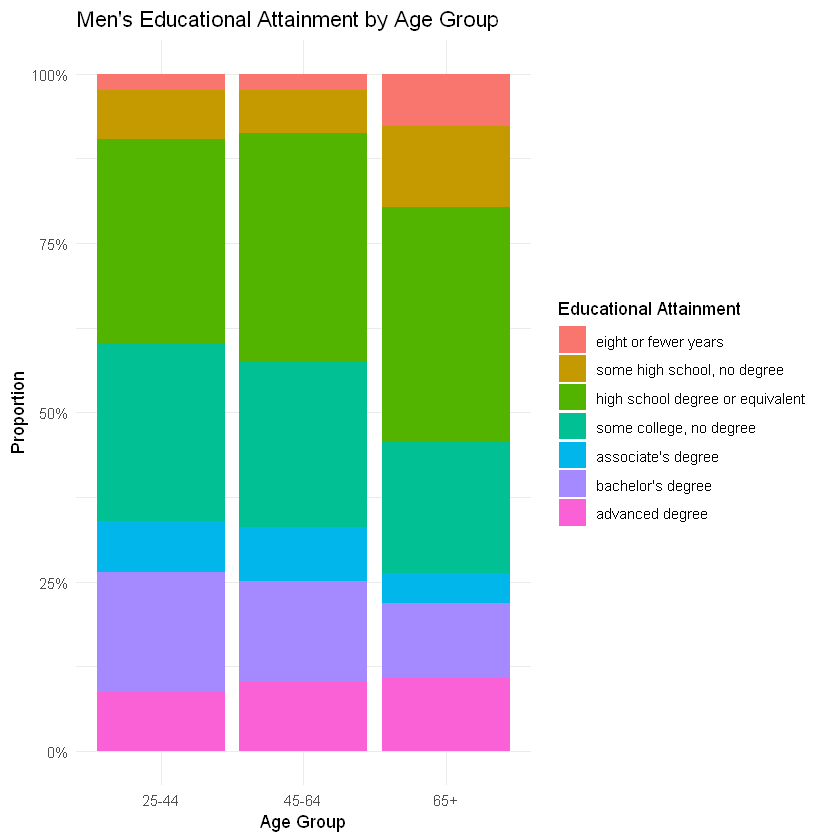

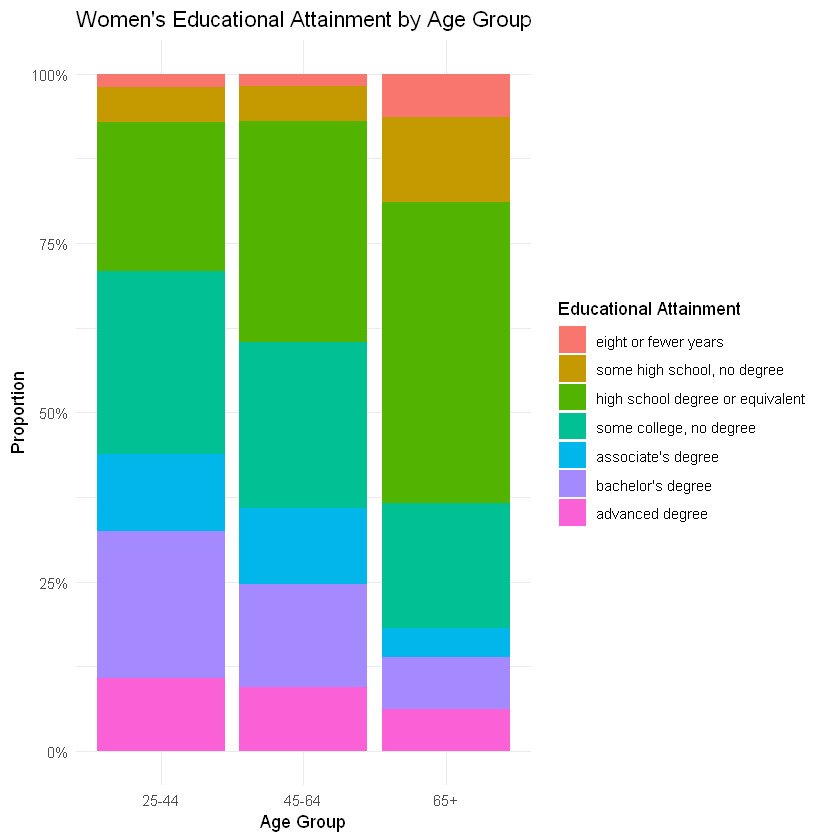

In [134]:
# stacked bar chart comparing age groups and educational attainment (men only)
ggplot(filter(dat, AGE >= 25 & SEX == 1), aes(x = AGE_CAT, fill = EDUC_RECODE)) +
  geom_bar(position = "fill") +
  labs(title = "Men's Educational Attainment by Age Group",
       x = "Age Group",
       y = "Proportion",
       fill = "Educational Attainment") +
  scale_y_continuous(labels = scales::percent_format()) +
  theme_minimal()#

# stacked bar chart comparing age groups and educational attainment (women only)
ggplot(filter(dat, AGE >= 25 & SEX == 2), aes(x = AGE_CAT, fill = EDUC_RECODE)) +
  geom_bar(position = "fill") +
  labs(title = "Women's Educational Attainment by Age Group",
       x = "Age Group",
       y = "Proportion",
       fill = "Educational Attainment") +
  scale_y_continuous(labels = scales::percent_format()) +
  theme_minimal()

This comparison shows us that a lot of this shift in educational attainment we are seeing is due to a shift in women's educational attainment specifically.  While men's educational attainment has also changed, the difference between age groups is not nearly as significant as it is for women.

We also see interesting differences between men's and women's educational attainment.  Let's take a look at the cross-tabulations for men and women seperately.

In [135]:
# men only
calculate_percentage_cross_tab(filter(dat, AGE >= 25 & SEX == 1), AGE_CAT, EDUC_RECODE) %>% print(n = Inf)

# A tibble: 21 x 4
   AGE_CAT EDUC_RECODE                          n Percentage
   <fct>   <fct>                            <int>      <dbl>
 1 25-44   eight or fewer years               260       2.38
 2 25-44   some high school, no degree        794       7.28
 3 25-44   high school degree or equivalent  3288      30.1 
 4 25-44   some college, no degree           2861      26.2 
 5 25-44   associate's degree                 826       7.57
 6 25-44   bachelor's degree                 1930      17.7 
 7 25-44   advanced degree                    949       8.70
 8 45-64   eight or fewer years               349       2.37
 9 45-64   some high school, no degree        948       6.45
10 45-64   high school degree or equivalent  4952      33.7 
11 45-64   some college, no degree           3583      24.4 
12 45-64   associate's degree                1173       7.98
13 45-64   bachelor's degree                 2195      14.9 
14 45-64   advanced degree                   1504      10.2 
15 65

In [136]:
# women only
calculate_percentage_cross_tab(filter(dat, AGE >= 25 & SEX == 2), AGE_CAT, EDUC_RECODE) %>% print(n = Inf)

# A tibble: 21 x 4
   AGE_CAT EDUC_RECODE                          n Percentage
   <fct>   <fct>                            <int>      <dbl>
 1 25-44   eight or fewer years               215       1.92
 2 25-44   some high school, no degree        587       5.23
 3 25-44   high school degree or equivalent  2464      22.0 
 4 25-44   some college, no degree           3040      27.1 
 5 25-44   associate's degree                1276      11.4 
 6 25-44   bachelor's degree                 2433      21.7 
 7 25-44   advanced degree                   1203      10.7 
 8 45-64   eight or fewer years               291       1.89
 9 45-64   some high school, no degree        775       5.04
10 45-64   high school degree or equivalent  5032      32.7 
11 45-64   some college, no degree           3776      24.5 
12 45-64   associate's degree                1725      11.2 
13 45-64   bachelor's degree                 2326      15.1 
14 45-64   advanced degree                   1460       9.49
15 65

There are some interesting differences in educational attainment for men compared to women.  In general, women in the youngest generation are completing more education than their male counterparts.

Percent of the 25-44 population with no high school diploma or equivalent:
* 10.22% (3.55% + 6.67%) of men aged 25-44
* 7.11% (2.78% + 4.33%) of women aged 25-44

Percent of the 25-44 population with a Bachelor's degree or more:
* 35.8% (23.5% + 12.3%) of men aged 25-44
* 45.5% (27.9% + 17.6%) of women aged 25-44